---
authors: Freek Pols
updated: december 3, 2025
---
# Bepaling van warmtecapaciteit van een onbekend materiaal

**Namen:** Oscar Pouw, Carsten Schroevers


# Introductie

Onbekende materialen kunnen geïdentificeerd worden door hun eigenschappen te meten. Een van deze eigenschappen is de warmtecapaciteit. In dit practicum gaan we de warmtecapaciteit van een onbekend materiaal bepalen door middel van een calorimeter experiment. Daarbij wordt een bepaalde massa van het materiaal naar een bekende temperatuur gebracht waarna het in een bekende hoeveelheid water met bekende temperatuur wordt geplaatst. Door de temperatuur van het water te meten na het mengen kan de warmtecapaciteit van het onbekende materiaal worden berekend.

# Theorie

De soortelijke warmte $c$ van een materiaal is gedefinieerd als de hoeveelheid warmte $Q$ die nodig is om de temperatuur $T$ van een kilogram van het materiaal met één graad Celsius (of één Kelvin) te verhogen:

$$
    c = \frac{Q}{m \Delta T}
$$ (eq:heat_capacity)

Waarbij $Q$ de hoeveelheid warmte in Joules is, $m$ de massa in kilogram is en $\Delta T$ de verandering in temperatuur is. Gegeven de wet van Black, die stelt dat de totale hoeveelheid warmte in een geïsoleerd systeem constant blijft, kunnen we de warmte die het onbekende materiaal verliest gelijkstellen aan de warmte die het water opneemt:

$$
    Q_{materiaal} = -Q_{water} 
$$ (eq:black)

wanneer we de massa's en de begintemperaturen van beide systemen kennen, maar slechts een van de twee soortelijke warmtes, kunnen we de onbekende soortelijke warmte berekenen. We combineren vergelijkingen [](#eq:heat_capacity) en [](#eq:black) om de volgende vergelijking te krijgen:

$$
    T_e = \frac{c_w m_w T_{w,b}+c_m m_m T_{m,b}}{c_w m_w + c_m m_m}
$$ (eq:combined)

Waarbij de subscripts $b$ en $e$ respectievelijk staan voor begintoestand en eindtoestand, $w$ voor water en $m$ voor het onbekende materiaal.

Bij metingen aan verschillende massa's van het onbekende materiaal en vervolgens een least square fit aan bovenstaande vergelijking kunnen we een precieze waarde voor de soortelijke warmte van het onbekende materiaal bepalen. Dat is, wanneer de warmtecapaciteit van bijvoorbeeld de beker te verwaarlozen is.


# Methode en materialen

## Ontwerp
De bovenstaande theorie wordt gebruikt om de soortelijke warmte van een onbekend materiaal te bepalen. Het experiment bestaat uit het verwarmen van verschillende massa's van het onbekende materiaal tot een bekende temperatuur, waarna het in een bekende hoeveelheid water met bekende temperatuur wordt geplaats. Door de temperatuur van het water te meten na het mengen kan de warmtecapaciteit van het onbekende materiaal worden berekend. Om de tijd voor het meten van meerdere materialen te reduceren, worden de data van de verschillende groepen in het lokaal samengevoegd. Van tevoren is afgesproken welke massa's door welke groep worden gemeten, en hoeveel water er gebruikt wordt.

## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Calorimeter
- Thermometer of temperatuursensor
- Verwarmingsbron 
- Diverse massablokjes van onbekend materiaal
- Weegschaal
- Water
- Maatcilinder of maatbeker


## Reconstructie van de opstelling
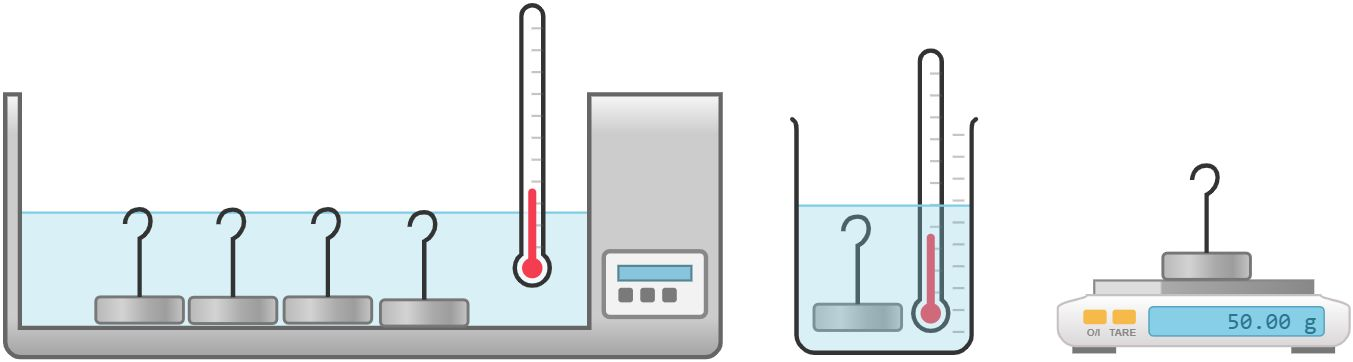

## Procedure
Bepaal de begintemperaturen.
Hevel het aantal afgesproken massa's in de maatbeker. 
Roer voorzicht zodat de temperatuur homogeen is.
Noteer de hoogste gemeten temperatuur, dit is $T_e$.
Wissel de metingen uit met de andere groepen en voer de data-analyse uit.


# Meetgegevens


C:\Users\carst\AppData\Local\Temp\ipykernel_14188\2980928299.py:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  plt.plot(m_block, temp_water_aftertime, 'k.', label='Meetpunten',color = "blue")


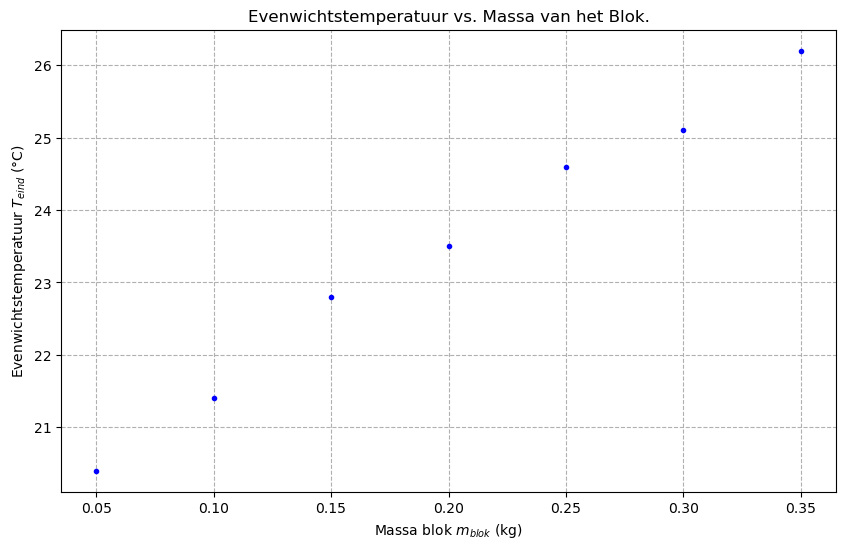

In [224]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


temp_block = 61.3
m_block = np.array([0.05,0.1,0.15,0.2,0.25,0.30,0.35])
temp_water_begin = 19.2
temp_water_aftertime = np.array([20.4,21.4,22.8,23.5,24.6,25.1,26.2])
c_water = 4186 #J/kg/K
m_water = 0.2 #kg
m_blok = 0.05 #kg
c_lit = 450 
unc_m_blok = 0.002
unc_m_wat = 0.02
unc_T_general = 0.2 

plt.figure(figsize=(10, 6))
plt.plot(m_block, temp_water_aftertime, 'k.', label='Meetpunten',color = "blue")
plt.title('Evenwichtstemperatuur vs. Massa van het Blok.')
plt.xlabel('Massa blok $m_{blok}$ (kg)')
plt.ylabel('Evenwichtstemperatuur $T_{eind}$ (°C)')
plt.grid(True, linestyle='--')

## Data analyse

In [225]:
def temp(m_blok,c_blok):
    return (c_blok * temp_block * m_blok + c_water * temp_water_begin * m_water)/(c_water * m_water + m_blok * c_blok)

values, cov = curve_fit(temp,m_block,temp_water_aftertime)
xtestvalues = np.linspace(np.min(m_block),np.max(m_block),1000)

#calculating value based on the fit
y_fit = temp(values[0],xtestvalues)
cblokcalc = values[0]
unc_c_blok_fit = np.sqrt(cov[0,0])

## Onzekerheden 

De onzekerheid in de berekening van de soortelijke warmte van de stof kan worden berekend met: 

$$\Delta c_m = \sqrt{ \left( \frac{\partial c_m}{\partial m_w} \Delta m_w \right)^2 + \left( \frac{\partial c_m}{\partial m_m} \Delta m_m \right)^2 + \left( \frac{\partial c_m}{\partial T_{w,b}} \Delta T_{w,b} \right)^2 + \left( \frac{\partial c_m}{\partial T_{m,b}} \Delta T_{m,b} \right)^2 + \left( \frac{\partial c_m}{\partial T_e} \Delta T_e \right)^2 }$$

In [226]:

# 1. Partial Derivatives
# d_cm/d_mw

# 2. Partial Derivatives (Gradients)
# d_cm/d_mw
dcm_dmw = (c_water * (temp_water_aftertime - temp_water_begin)) / \
          (m_block * (temp_block - temp_water_aftertime))
    
# d_cm/d_mm
dcm_dmm = - (c_water * m_water * (temp_water_aftertime - temp_water_begin)) / \
            (m_block**2 * (temp_block - temp_water_aftertime))
    
# d_cm/d_Twb
dcm_dTwb = - (c_water * m_water) / \
             (m_block * (temp_block - temp_water_aftertime))
    
# d_cm/d_Tmb
dcm_dTmb = - (c_water * m_water * (temp_water_aftertime - temp_water_begin)) / \
             (m_block * (temp_block - temp_water_aftertime)**2)
    
# d_cm/d_Te
dcm_dTe = (c_water * m_water * (temp_block - temp_water_begin)) / \
            (m_block * (temp_block - temp_water_aftertime)**2)

# 3. Final Uncertainty Calculation using your variables
# Quadrature sum of (Derivative * Uncertainty)^2
unc_c_blok = np.mean(np.sqrt(
    (dcm_dmw * unc_m_wat)**2 +
    (dcm_dmm * unc_m_blok)**2 +
    (dcm_dTwb * unc_T_general)**2 +
    (dcm_dTmb * unc_T_general)**2 +
    (dcm_dTe * unc_T_general)**2 +
    unc_c_blok_fit**2
))


## Resultaten

Het procentueel verschil tussen de literatuurwaarde en de experimentele waarde luidt als volgt: 

$$\text{Percent Error} = \left| \frac{T - E}{T} \right| \times 100\%$$

Waarbij E de experimentele waarde is en T de literatuurwaarde. De formule voor een strijdigheidsanalyse is als volgt: 

$$|c_{m} - c_{accepted}| \leq 2\Delta c_{m}$$

In [227]:
#percentual error
percent_error = np.abs((c_lit - cblokcalc) / c_lit) * 100

#Agreement analysis
discrepancy = np.abs(cblokcalc - c_lit)
agreement = "YES" if discrepancy <= (2 * unc_m_blok) else "NO"

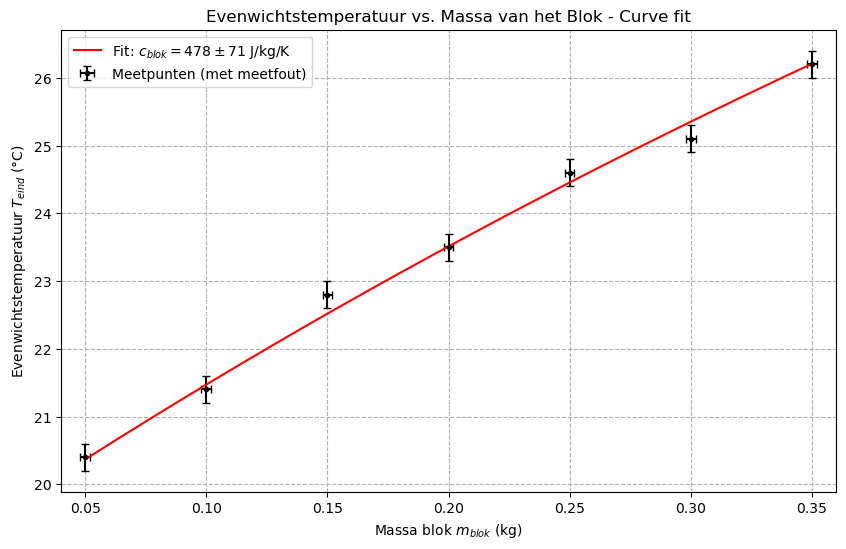

In [228]:
#Grafiek voor de fit.
plt.figure(figsize=(10, 6))
plt.xlabel('Massa blok $m_{blok}$ (kg)')
plt.ylabel('Evenwichtstemperatuur $T_{eind}$ (°C)')
plt.xlim(0.04,0.36)

plt.errorbar(m_block, temp_water_aftertime, 
             yerr=unc_T_general, xerr=unc_m_blok, 
             fmt='k.', capsize=3, label='Meetpunten (met meetfout)')

plt.plot(xtestvalues, y_fit, 'r-', 
         label=f'Fit: $c_{{blok}} = {cblokcalc:.0f} \\pm {unc_c_blok:.0f}$ J/kg/K')

plt.title('Evenwichtstemperatuur vs. Massa van het Blok - Curve fit')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

In [229]:
# Laatste Tabel:
print(f"{'Metric':<30} | {'Value'}")
print("-" * 45)
print(f"{'Final Experimental C (J/kg/K)':<30} | {cblokcalc:.1f} ± {unc_c_blok:.1f}")
print(f"{'Literature Value (J/kg/K)':<30} | {c_lit:.1f}")
print(f"{'Percentual Difference (%)':<30} | {percent_error:.1f}%")
print(f"{'Agreement Analysis (2Δ)':<30} | {agreement}")

Metric                         | Value
---------------------------------------------
Final Experimental C (J/kg/K)  | 477.6 ± 70.8
Literature Value (J/kg/K)      | 450.0
Percentual Difference (%)      | 6.1%
Agreement Analysis (2Δ)        | NO


# Discussie en conclusie

Het doel van dit experiment was om de identiteit van een stof te achterhalen door zijn soortelijke warmte $c$ te bepalen. Er zijn warme blokjes in het water gedompeld, waarna de verschillende temperaturen zijn gemeten. De waarde van C was uitgekomen op $477.6 \pm 70.8$ J/kg/K. De waarde was niet in statistische overeenkomst. Wij concluderen dat de onbekende stof ijzer is. De onzekerheid was aanzienlijk, maar niet onverwachts geziene de schaal van het experiment.